In [2]:
import matplotlib.pyplot as plt
# 设置中文字体支持
import matplotlib.font_manager as fm
# 备选中文字体列表
chinese_fonts = [
    "SimHei",           # Windows
    "Heiti TC",         # macOS
    "WenQuanYi Micro Hei",  # Linux
    "Microsoft YaHei",  # 微软雅黑
    "Arial Unicode MS", # 备选
]

# 获取系统可用字体
available_fonts = {f.name for f in fm.fontManager.ttflist}

# 查找第一个可用的中文字体
for font in chinese_fonts:
    if font in available_fonts:
        plt.rcParams["font.family"] = font
        break

plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

### 240718

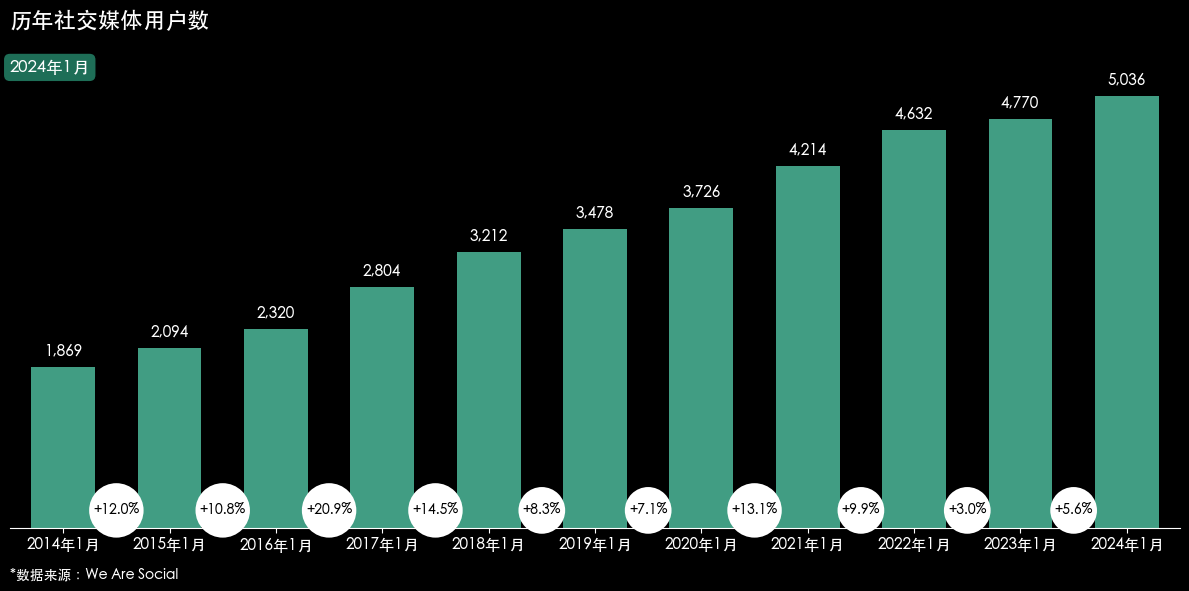

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# 数据
years = [f"{y}年1月" for y in range(2014, 2025)]
users = [1869, 2094, 2320, 2804, 3212, 3478, 3726, 4214, 4632, 4770, 5036]
growth = [12.0, 10.8, 20.9, 14.5, 8.3, 7.1, 13.1, 9.9, 3.0, 5.6]

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('black')
ax.set_facecolor('black')

# 绘制柱状图
bars = ax.bar(years, users, color='#419D83', width=0.6)

# 添加柱顶用户数标签
for bar, value in zip(bars, users):
    ax.text(bar.get_x() + bar.get_width()/2, value + 100,
            f"{value:,}", ha='center', va='bottom', color='white', fontsize=11)

# 添加增长率标签（白底圆框模拟）
for i, (bar, pct) in enumerate(zip(bars[1:], growth)):
    # x = bar.get_x() + bar.get_width() / 2
    x = bar.get_x() - bar.get_width() / 3
    y = 200  # 设置在下方但不压缩主图
    ax.text(x, y, f"+{pct:.1f}%", ha='center', va='center',
            fontsize=10, color='black',
            bbox=dict(boxstyle="circle,pad=0.3", facecolor='white', edgecolor='none'))

# 坐标轴美化
ax.set_ylim(0, 5500)
ax.set_xlim(-0.5, len(years)-0.5)
ax.set_yticks([])
ax.set_xticks(np.arange(len(years)))
ax.set_xticklabels(years, color='white', fontsize=11)
ax.spines[['left', 'top', 'right']].set_visible(False)
ax.spines['bottom'].set_color('white')
ax.tick_params(axis='x', colors='white')

# 左上角主标题框
plt.text(-0.5, 5300, "2024年1月", fontsize=12, color='white',
         bbox=dict(facecolor='#1E6E57', boxstyle="round,pad=0.4"))
plt.title("历年社交媒体用户数", fontsize=16, color='white', loc='left', pad=20)

# 数据来源
plt.text(-0.5, -600, "*数据来源：We Are Social", color='white', fontsize=10)

plt.tight_layout()
plt.show()


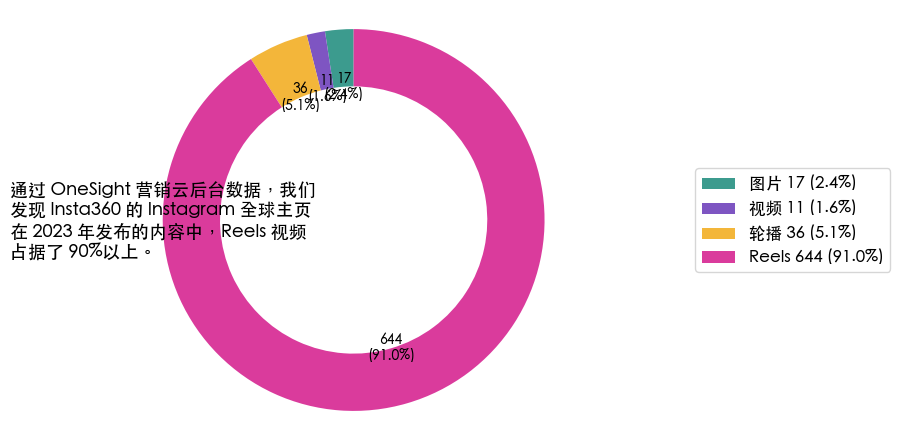

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# 数据
labels = ['图片', '视频', '轮播', 'Reels']
counts = [17, 11, 36, 644]
colors = ['#3C9B8E', '#7E55C2', '#F3B63A', '#DA3B9C']

# 计算百分比
total = sum(counts)
percentages = [count / total for count in counts]
label_texts = [f"{label} {count} ({p:.1%})" for label, count, p in zip(labels, counts, percentages)]

# 绘图
fig, ax = plt.subplots(figsize=(9, 4.5))

# 环形图
wedges, texts = ax.pie(
    counts,
    colors=colors,
    startangle=90,
    wedgeprops=dict(width=0.3)
)

# 添加数值标注在图中扇区内
for i, wedge in enumerate(wedges):
    angle = (wedge.theta2 + wedge.theta1) / 2
    x = 0.7 * np.cos(np.deg2rad(angle))
    y = 0.7 * np.sin(np.deg2rad(angle))
    ax.text(x, y, f"{counts[i]}\n({percentages[i]:.1%})",
            ha='center', va='center', fontsize=10, color='black')

# 图例放右侧
ax.legend(
    wedges,
    label_texts,
    loc='center left',
    bbox_to_anchor=(1, 0.5),
    fontsize=12
)

# 添加说明文字
description = (
    "通过 OneSight 营销云后台数据，我们\n"
    "发现 Insta360 的 Instagram 全球主页\n"
    "在 2023 年发布的内容中，Reels 视频\n"
    "占据了 90%以上。"
)
plt.text(-1.8, 0.2, description, fontsize=13, va='top')

# 美化图形
plt.axis('equal')  # 保证圆形
plt.tight_layout()
plt.show()


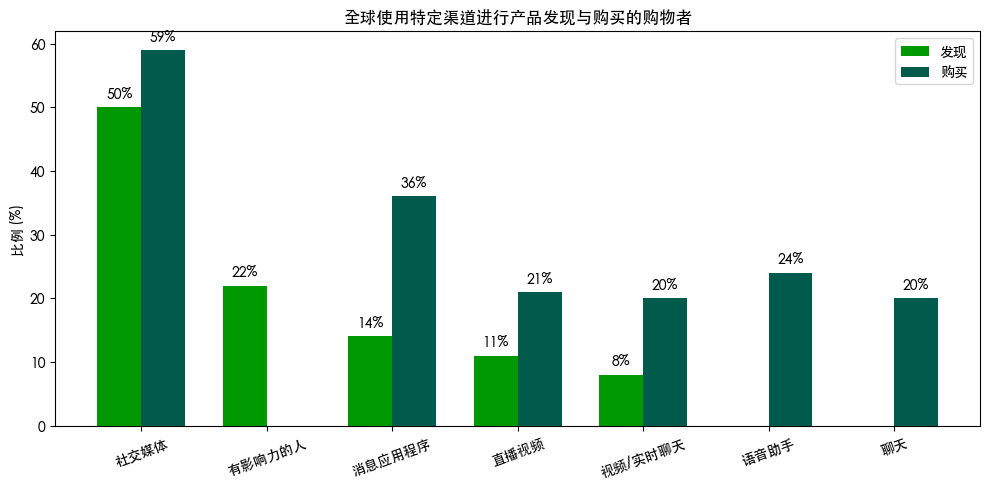

In [12]:
import matplotlib.pyplot as plt
import numpy as np



# 渠道
channels = ['社交媒体', '有影响力的人', '消息应用程序', '直播视频', '视频/实时聊天', '语音助手', '聊天']
# 发现阶段数据
discover = [50, 22, 14, 11, 8, 0, 0]
# 购买阶段数据
purchase = [59, 0, 36, 21, 20, 24, 20]

# 横坐标位置
x = np.arange(len(channels))
bar_width = 0.35

# 绘图
fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - bar_width/2, discover, width=bar_width, label='发现', color='#009800')
bars2 = ax.bar(x + bar_width/2, purchase, width=bar_width, label='购买', color='#005B4C')

# 添加数值标签
for bar in bars1:
    height = bar.get_height()
    if height > 0:
        ax.text(bar.get_x() + bar.get_width()/2, height + 1, f'{int(height)}%', ha='center', va='bottom', fontsize=10)

for bar in bars2:
    height = bar.get_height()
    if height > 0:
        ax.text(bar.get_x() + bar.get_width()/2, height + 1, f'{int(height)}%', ha='center', va='bottom', fontsize=10)

# 其他设置
ax.set_xticks(x)
ax.set_xticklabels(channels, rotation=20)
ax.set_ylabel('比例 (%)')
ax.set_title('全球使用特定渠道进行产品发现与购买的购物者')
ax.legend()
plt.tight_layout()
plt.show()
